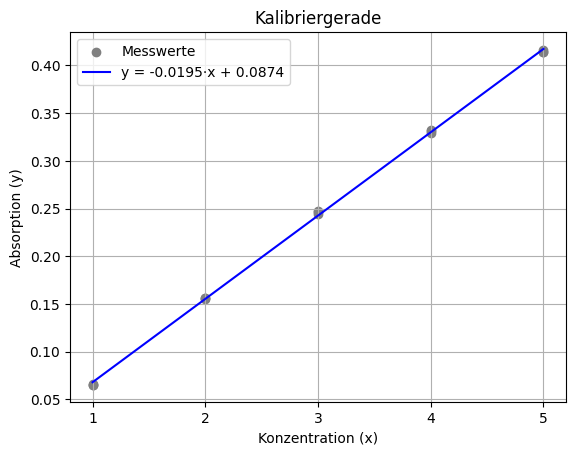

Regressionsgleichung:
y = -0.019543 * x + 0.087377
s_y = 0.0027832051252522994
Konzentration Messlösung c_mess = -0.22366764582458948 mg/L
Konzentration Probe c_Probe(Zink) = -22.36676458245895 mg/L
s_xmess = 0.02159457402675032
s_cProbe = 0.0002159457402675032
m_ZnSO4 = -2.804357311426043
t = 3.182
c_Probe = -22.3668 ± 0.0007 mg/L (n = 15; s_c = 0.0002159457402675032; P = 95%)
m_ZnSO4 = -2.8044 ± 0.0005 mg/L (n = 15; s_c = 0.0002159457402675032; P = 95%) 
------------------------------------------------------------
x_bar = 3.0
x = 2     1
3     1
4     1
5     2
6     2
7     2
8     3
9     3
10    3
11    4
12    4
13    4
14    5
15    5
16    5
Name: 0, dtype: int64


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Pfad und Datei
ordner = "/Users/sascha0404/Downloads"
datei = "Daten_AAS.xlsx"
pfad = os.path.join(ordner, datei)

sheet_name = "Tabelle1"

# Excel laden
df = pd.read_excel(pfad, sheet_name=sheet_name, header=None)

# Messwerte holen (ab Zeile 3)
roh_x = df.iloc[2:, 0]   # Konzentrationen / Probenstufen
roh_y = df.iloc[2:, 1]   # Abs.

# In Zahlen umwandeln
x = pd.to_numeric(roh_x, errors="coerce")
y = pd.to_numeric(roh_y.astype(str).str.replace(",", "."), errors="coerce")

# Leere Zeilen entfernen
maske = (~x.isna()) & (~y.isna())
x = x[maske]
y = y[maske]

# ------------------ Regression ------------------
b, a = np.polyfit(x, y, 1)      # m = Steigung, b = Achsenabschnitt
y_gerade = b * x + a            # ŷ (y-dach)

n = len(y)

# Standardabweichung der Regression s_y
s_y = np.sqrt(np.sum((y - y_gerade)**2) / (n - 2))

# ------------------ Messprobe ------------------
# HIER: Absorptionswert deiner Probe eintragen:
y_mess = 0.3000   # Beispielwert! -> durch deinen echten Wert ersetzen

# Konzentration der Messlösung aus der Kalibriergeraden
c_mess = a / b

# Verdünnungsfaktor und Konzentration der ursprünglichen Probe
V_f = (100/10) * (50/5)     # aus deinem Ansatz
c_Probe = c_mess / (1 / V_f)

# ------------------ s_x nach deiner Formel ------------------
x_bar = np.mean(x)

s_xmess = (s_y / b) * np.sqrt(
    (1 / n) +
    (y_mess**2 / (b**2 * np.sum((x - x_bar)**2))))

s_cProbe = s_xmess * 1/V_f

#Masse an ZnSO4 bestimmen
V_Probe = 0.05 #L
M_ZnSO4 = 161.44 #g/mol
M_Zn = 64.38 #g/mol
m_Zn = c_Probe * V_Probe

m_ZnSO4 = m_Zn * M_ZnSO4/M_Zn

#Wissenschaftliche Schreibweise c_Probe
# Freiheitsgrade (bei dir: Anzahl der Kalibrierpunkte)
nu = n - 2

# t-Wert für 95 % (typisch für n ≈ 5 → nu ≈ 3)
t = 3.182   # kannst du bei Bedarf aus der t-Tabelle anpassen

# erweiterte Unsicherheit
u_cProbe = t * s_cProbe

#Wissenschaftliche Schreibweise der Masse von ZnSO4
# Freiheitsgrade (bei dir: Anzahl der Kalibrierpunkte)
nu = n - 2

# t-Wert für 95 % (typisch für n ≈ 5 → nu ≈ 3)
t = 3.182   # kannst du bei Bedarf aus der t-Tabelle anpassen

# erweiterte Unsicherheit
k = M_ZnSO4/M_Zn
u_mProbe = k * s_cProbe



# ------------------ Plot ------------------
plt.figure()
plt.scatter(x, y, color="grey", label="Messwerte")
plt.plot(x, y_gerade, color="blue", label=f"y = {a:.4f}·x + {b:.4f}")
plt.xlabel("Konzentration (x)")
plt.xticks(np.unique(x.astype(int)))
plt.ylabel("Absorption (y)")
plt.title("Kalibriergerade")
plt.legend()
plt.grid(True)
plt.show()

# ------------------ Ausgabe ------------------
print("Regressionsgleichung:")
print(f"y = {a:.6f} * x + {b:.6f}")
print("s_y =", s_y)
print(f"Konzentration Messlösung c_mess = {c_mess} mg/L")
print(f"Konzentration Probe c_Probe(Zink) = {c_Probe} mg/L")
print("s_xmess =", s_xmess)
print("s_cProbe =", s_cProbe)
print("m_ZnSO4 =", m_ZnSO4)
print("t =", t)
print(f"c_Probe = {c_Probe:.4f} ± {u_cProbe:.4f} mg/L (n = {n}; s_c = {s_cProbe}; P = 95%)")
print(f"m_ZnSO4 = {m_ZnSO4: .4f} ± {u_mProbe:.4f} mg/L (n = {n}; s_c = {s_cProbe}; P = 95%) ")
print("-" * 60)
print("x_bar =", x_bar)
print("x =", x)

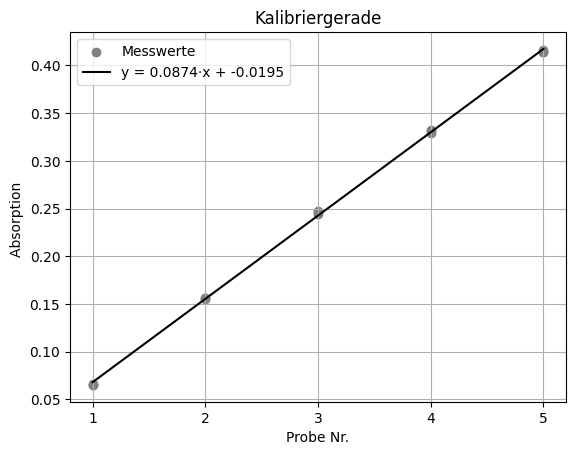

Regressionsgleichung:
y = 0.087377 * x + -0.019543
y_gerade = 2     0.067833
3     0.067833
4     0.067833
5     0.155210
6     0.155210
7     0.155210
8     0.242587
9     0.242587
10    0.242587
11    0.329963
12    0.329963
13    0.329963
14    0.417340
15    0.417340
16    0.417340
Name: 0, dtype: float64
s_y = 0.0027832051252522994
Konzentration Messlösung c_mess = -0.22366764582458948 mg/L
Konzentration Probe c_Probe(Zink) = -44.7335291649179 mg/L
s_xmess = 0.14594210098620505
s_cProbe = 29.188420197241012
m_ZnSO4 = -28.04357311426043
s_mProbe =  36.5966 mg
t = 2.16
c_Probe = -44.7335 ± 63.0470 mg/L (n = 15; s_c = 29.188420197241012; P = 95%)
m_ZnSO4 = -28.0436 ± 79.0487 mg (n = 15; s_c = 29.188420197241012; P = 95%) 
------------------------------------------------------------
x_i = [0.  0.2 0.4 0.6 0.8]
x_bar = 0.4
b = 0.08737666666666669
n = 15


In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Pfad und Datei
ordner = "/Users/sascha0404/Downloads"
datei = "Daten_AAS.xlsx"
pfad = os.path.join(ordner, datei)

sheet_name = "Tabelle1"

# Excel laden
df = pd.read_excel(pfad, sheet_name=sheet_name, header=None)

# Messwerte holen (ab Zeile 3)
roh_x = df.iloc[2:, 0]   # Konzentrationen / Probenstufen
roh_y = df.iloc[2:, 1]   # Abs.

# In Zahlen umwandeln
x = pd.to_numeric(roh_x, errors="coerce")
y = pd.to_numeric(roh_y.astype(str).str.replace(",", "."), errors="coerce")

# Leere Zeilen entfernen
maske = (~x.isna()) & (~y.isna())
x = x[maske]
y = y[maske]

# ------------------ Regression ------------------
b, a = np.polyfit(x, y, 1)      # m = Steigung, b = Achsenabschnitt
y_gerade = b * x + a            # ŷ (y-dach)

n = 15

# Standardabweichung der Regression s_y
z = np.sum((y - y_gerade)**2)
s_y = np.sqrt(z / (n - 2))

# ------------------ Messprobe ------------------

y_mess = 0.252793333   # Mittelwert der y- Werte

# Konzentration der Messlösung aus der Kalibriergeraden
# A = a + b*c  ->  c = (A - a)/b
c_mess =  a / b      # SKALAR

# Verdünnungsfaktor und Konzentration der ursprünglichen Probe
V_f = (100/5) * (50/5)
c_Probe = c_mess * V_f      # statt c_mess / (1 / V_f)

# ------------------ s_x nach deiner Formel ------------------
x_i = np.array([0.0, 0.2, 0.4, 0.6, 0.8])   # <- WICHTIG: Array!
x_bar = np.mean(x_i)


s_xmess = (s_y / b) * np.sqrt(
    (1 / n) +
    (y_mess**2 / (b**2 * np.sum((x_i - x_bar)**2))))

s_cProbe = s_xmess * V_f

#Masse an ZnSO4 bestimmen
V_Probe = 0.5 #L
M_ZnSO4 = 161.44 #g/mol
M_Zn = 64.38 #g/mol
m_Zn = c_Probe * V_Probe

m_ZnSO4 = m_Zn * V_Probe * (M_ZnSO4/M_Zn)

#Wissenschaftliche Schreibweise c_Probe
# Freiheitsgrade (bei dir: Anzahl der Kalibrierpunkte)
nu = n - 2

# t-Wert für 95 % (typisch für n ≈ 5 → nu ≈ 3)
t = 2.160   # kannst du bei Bedarf aus der t-Tabelle anpassen

# erweiterte Unsicherheit
T_cProbe = t * s_cProbe

#Wissenschaftliche Schreibweise der Masse von ZnSO4
# Freiheitsgrade (bei dir: Anzahl der Kalibrierpunkte)
nu = n - 2


# erweiterte Unsicherheit
k = M_ZnSO4/M_Zn
s_mProbe = k * s_cProbe * V_Probe
T_mProbe = t * s_mProbe




# ------------------ Plot ------------------
plt.figure()
plt.scatter(x, y, color="grey", label="Messwerte")
plt.plot(x, y_gerade, color="black", label=f"y = {b:.4f}·x + {a:.4f}")
plt.xlabel("Probe Nr.")
plt.xticks(np.unique(x.astype(int)))
plt.ylabel("Absorption ")
plt.title("Kalibriergerade")
plt.legend()
plt.grid(True)
plt.show()

# ------------------ Ausgabe ------------------
print("Regressionsgleichung:")
print(f"y = {b:.6f} * x + {a:.6f}")
print("y_gerade =", y_gerade)
print("s_y =", s_y)
print(f"Konzentration Messlösung c_mess = {c_mess} mg/L")
print(f"Konzentration Probe c_Probe(Zink) = {c_Probe} mg/L")
print("s_xmess =", s_xmess)
print("s_cProbe =", s_cProbe)
print("m_ZnSO4 =", m_ZnSO4)
print(f"s_mProbe = {s_mProbe: .4f} mg")
print("t =", t)
print(f"c_Probe = {c_Probe:.4f} ± {T_cProbe:.4f} mg/L (n = {n}; s_c = {s_cProbe}; P = 95%)")
print(f"m_ZnSO4 = {m_ZnSO4: .4f} ± {T_mProbe:.4f} mg (n = {n}; s_c = {s_cProbe}; P = 95%) ")

print("-" * 60)

print("x_i =", x_i)
print("x_bar =", x_bar)
print("b =", b)
print("n =", n)

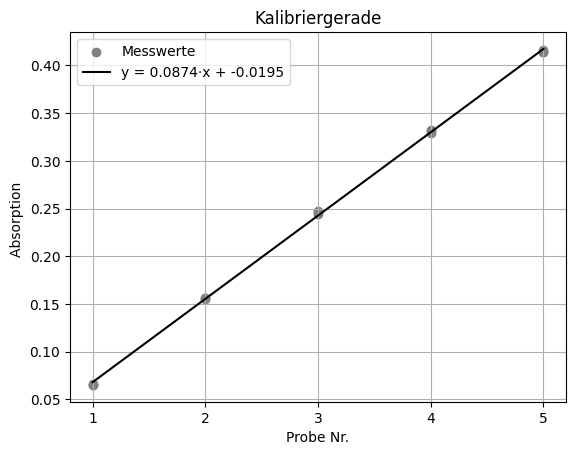

Regressionsgleichung:
y = 0.087377 * x + -0.019543
y_gerade = 2     0.067833
3     0.067833
4     0.067833
5     0.155210
6     0.155210
7     0.155210
8     0.242587
9     0.242587
10    0.242587
11    0.329963
12    0.329963
13    0.329963
14    0.417340
15    0.417340
16    0.417340
Name: 0, dtype: float64
s_y = 0.0027832051252522994
Konzentration Messlösung c_mess = -0.22366764582458948 mg/L
Konzentration Probe c_Probe(Zink) = -44.7335291649179 mg/L
s_xmess = 0.4099298127123219
s_cProbe = 81.98596254246438
m_ZnSO4 = -55.239545382833384
s_mProbe =  101.2410 mg
t = 2.16
c_Probe = -44.7335 ± 177.0897 mg/L (n = 15; s_c = 81.98596254246438; P = 95%)
m_ZnSO4 = -55.2395 ± 218.6806 mg (n = 15; s_c = 81.98596254246438; P = 95%) 
------------------------------------------------------------
x_i = [0.  0.2 0.4 0.6 0.8]
x_bar = 0.4
b = 0.08737666666666669
n = 15


In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Datei im gleichen Ordner
pfad = "Daten AAS.xlsx"
sheet_name = "Tabelle1"

# Excel laden
df = pd.read_excel(pfad, sheet_name=sheet_name, header=None)

# Messwerte holen (ab Zeile 3)
roh_x = df.iloc[2:, 0]   # Konzentrationen / Probenstufen
roh_y = df.iloc[2:, 1]   # Abs.

x = pd.Series(x)
y = pd.Series(y)

# Leere Zeilen entfernen
maske = (~x.isna()) & (~y.isna())
x = x[maske]
y = y[maske]

# ------------------ Regression ------------------
b, a = np.polyfit(x, y, 1)      # m = Steigung, b = Achsenabschnitt
y_gerade = b * x + a            # ŷ (y-dach)

n = 15

# Standardabweichung der Regression s_y
z = np.sum((y - y_gerade)**2)
s_y = np.sqrt(z / (n - 2))

# ------------------ Messprobe ------------------

y_mess = 0.252793333   # Mittelwert der y- Werte

# Konzentration der Messlösung aus der Kalibriergeraden
# A = a + b*c  ->  c = (A - a)/b
c_mess =  a / b      # SKALAR

# Verdünnungsfaktor und Konzentration der ursprünglichen Probe
V_f = (100/5) * (50/5)     # = 100
c_Probe = c_mess * V_f      # statt c_mess / (1 / V_f)

# ------------------ s_x nach deiner Formel ------------------
x_i = np.array([0.0, 0.2, 0.4, 0.6, 0.8])   # <- WICHTIG: Array!
x_bar = np.mean(x_i)


s_xmess = (s_y / b) * np.sqrt(
    (1 / n) +
    (y_mess*2 / (b**2 * np.sum((x_i - x_bar)**2))))

s_cProbe = s_xmess * V_f

#Masse an ZnSO4 bestimmen
V_Probe = 0.5 #L
M_ZnSO4 = 161.47 #g/mol
M_Zn = 65.38 #g/mol
m_Zn = c_Probe * V_Probe

m_ZnSO4 = m_Zn  * (M_ZnSO4/M_Zn)

#Wissenschaftliche Schreibweise c_Probe
# Freiheitsgrade (bei dir: Anzahl der Kalibrierpunkte)
nu = n - 2

# t-Wert für 95 % (typisch für n ≈ 5 → nu ≈ 3)
t = 2.160   # kannst du bei Bedarf aus der t-Tabelle anpassen

# erweiterte Unsicherheit
T_cProbe = t * s_cProbe

#Wissenschaftliche Schreibweise der Masse von ZnSO4
# Freiheitsgrade (bei dir: Anzahl der Kalibrierpunkte)
nu = n - 2


# erweiterte Unsicherheit
k = M_ZnSO4/M_Zn
s_mProbe = k * s_cProbe * V_Probe
T_mProbe = t * s_mProbe




# ------------------ Plot ------------------
plt.figure()
plt.scatter(x, y, color="grey", label="Messwerte")
plt.plot(x, y_gerade, color="black", label=f"y = {b:.4f}·x + {a:.4f}")
plt.xlabel("Probe Nr.")
plt.xticks(np.unique(x.astype(int)))
plt.ylabel("Absorption ")
plt.title("Kalibriergerade")
plt.legend()
plt.grid(True)
plt.show()

# ------------------ Ausgabe ------------------
print("Regressionsgleichung:")
print(f"y = {b:.6f} * x + {a:.6f}")
print("y_gerade =", y_gerade)
print("s_y =", s_y)
print(f"Konzentration Messlösung c_mess = {c_mess} mg/L")
print(f"Konzentration Probe c_Probe(Zink) = {c_Probe} mg/L")
print("s_xmess =", s_xmess)
print("s_cProbe =", s_cProbe)
print("m_ZnSO4 =", m_ZnSO4)
print(f"s_mProbe = {s_mProbe: .4f} mg")
print("t =", t)
print(f"c_Probe = {c_Probe:.4f} ± {T_cProbe:.4f} mg/L (n = {n}; s_c = {s_cProbe}; P = 95%)")
print(f"m_ZnSO4 = {m_ZnSO4: .4f} ± {T_mProbe:.4f} mg (n = {n}; s_c = {s_cProbe}; P = 95%) ")

print("-" * 60)

print("x_i =", x_i)
print("x_bar =", x_bar)
print("b =", b)
print("n =", n)